# Apart from returns, what other variables would make a good ML model?

1) Risk & distribution stats (from prices)

What: realized vol/semivol, downside deviation, skew/kurtosis, rolling drawdowns, rolling betas/correlations, idiosyncratic vol.

Where: compute from Ticker.history() (OHLCV). yfinance provides split/dividend-adjusted series; you compute the stats. 
ranaroussi.github.io

2) Factor exposures / factor returns

What: exposures to market, size, value, momentum, profitability, investment; later map to tracking error and factor constraints.

Where: use Kenneth French Data Library for daily/monthly factor returns (FF3/FF5/MOM), then run rolling regressions to get exposures. 
mba.tuck.dartmouth.edu

Alt: WRDS mirror if you have access. 
WRDS

3) Fundamentals & quality ratios

What: valuation (PE, PB, EV/EBITDA), margins, growth, leverage, accruals, payout—useful for quality/low-risk tilts and constraint sets.

Where (yf): Ticker.get_income_stmt()/balance_sheet/cashflow/financials + trailing/quarterly/ttm helpers. 
ranaroussi.github.io

Alt: Nasdaq Data Link (Sharadar SF1) for point-in-time standardized fundamentals. 
Nasdaq Data Link
Nasdaq Data Docs

4) Analyst expectations & revisions

What: EPS/revenue estimates, surprise history, revisions, price targets; strong signals for short-horizon BO objectives.

Where (yf): get_earnings_estimate, get_revenue_estimate, get_eps_revisions, analyst_price_targets, get_earnings_history. 
ranaroussi.github.io

5) Events calendar

What: earnings dates, ex-dividends, splits; use to manage blackout windows or add event-aware penalties in the acquisition function.

Where (yf): get_earnings_dates() and calendar. 
ranaroussi.github.io
+1

6) Dividends & buybacks

What: dividend yield/growth, payout stability; shares-outstanding trends to proxy buybacks.

Where (yf): dividends, shares/get_shares_full, actions. 
ranaroussi.github.io

7) Options-implied metrics

What: 30-day IV, IV term structure/skew, put-call ratios—useful as regime/state variables and for downside-aware objectives (e.g., CVaR).

Where (yf): option_chain() for quotes; compute IV/term structure yourself. 
ranaroussi.github.io

Benchmarks: VIX as a market-wide implied vol proxy (also downloadable as ^VIX). Methodology: Cboe docs. 
CBOE
+1

8) Liquidity & microstructure

What: ADV, turnover, Amihud illiquidity, bid-ask/effective spread; helpful for turnover and transaction-cost penalties.

Where (yf): volume/turnover from history() (compute features). 
ranaroussi.github.io

Top-of-book spread/quotes: Polygon.io NBBO quotes; IEX Cloud also exposes real-time/historical quotes. 
Polygon
Postman
PublicAPI

9) Short interest & stock-loan/borrow costs

What: short interest %, days-to-cover, borrow fee/utilization; useful for squeeze/overcrowding risk and borrow-cost-aware objectives.

Where (official): FINRA bi-monthly short interest files + metadata/API guidance. 
FINRA
+2
FINRA
+2

Aggregated: Nasdaq short interest pages/API via Data Link; Polygon short-interest endpoint (mirrors FINRA). 
Nasdaq
Nasdaq Data Docs
Polygon

Borrow fees: Interactive Brokers SLB Rates (GUI/API). 
IBKR Guides
Interactive Brokers

10) Insider & institutional flows

What: insider transactions/holdings; institutional holders; changes can be priors or constraints.

Where (yf): insider_transactions, insider_purchases, insider_roster_holders, institutional_holders. 
ranaroussi.github.io

Primary source: SEC EDGAR APIs (submissions & XBRL). 
SEC
+1

11) ESG & controversies

What: aggregate ESG scores or governance red flags to build “soft” constraints or additional objectives.

Where (yf): sustainability (when available). 
ranaroussi.github.io

Alt: commercial providers (MSCI/Sustainalytics/Refinitiv) if you need coverage/consistency.

12) Macro & rates (for risk-free, constraints, & regimes)

What: risk-free (1M–10Y UST), term spreads, credit spreads, inflation, unemployment, PMI; use as context features or regime switches.

Where: FRED API (and fredapi Python wrapper). 
FRED
GitHub

In [2]:
import pandas as pd
import yfinance as yf
import warnings
from marketmaven.utils import get_current_date

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2023-01-01'
end = get_current_date()
interval = "1wk"

# Tickers of assets 
assets = ['AVEM', 'XMMO', 'ESGD', 'BYLD', 'ISCF', 'HYEM', 'VWOB', 'VNQI', 'VNQ', 'SNPE', 'AVES', 'IEF', 'VBK'] # , 'AGEPX', 'SWSSX', 'SWVXX' mutual funds 
assets.sort()
raw_data = yf.download(assets, start=start, end=end, auto_adjust=False, interval=interval)
data = raw_data.loc[:, ('Adj Close', slice(None))]
data.columns = assets
data

[*********************100%***********************]  13 of 13 completed


,AVEM,AVES,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB,XMMO
Date,,,,,,,,,,,,,
2023-01-01,4931.2862%,3920.3453%,1923.2243%,6300.3792%,1583.7643%,9017.6788%,2746.2938%,3389.0259%,20025.3540%,7618.7241%,3897.5052%,5350.4425%,7434.9533%
2023-01-08,5078.2387%,4030.5336%,1935.2982%,6528.2928%,1593.0715%,9073.5954%,2832.0595%,3494.6007%,21269.1284%,7962.7724%,3981.6566%,5403.5534%,7658.8844%
2023-01-15,5139.6236%,4072.8786%,1937.1353%,6567.0471%,1603.2232%,9090.0917%,2865.6431%,3475.2285%,21208.1238%,7918.5265%,4025.5619%,5453.2356%,7528.2585%
2023-01-22,5196.3589%,4097.9218%,1938.7978%,6620.5666%,1609.9915%,9076.3420%,2893.4488%,3558.0410%,21896.9208%,8157.8239%,4095.9934%,5463.5162%,7665.7623%
2023-01-29,5054.0573%,4004.1248%,1937.0485%,6602.1111%,1599.8389%,9037.8448%,2875.2125%,3607.9220%,22668.3716%,8302.3064%,4057.5764%,5448.0968%,7766.9228%
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-20,7052.9999%,5515.0002%,2243.9558%,9037.9997%,1977.4057%,9443.1519%,3977.9999%,5709.0000%,28717.0013%,9173.0003%,4634.0000%,6501.4648%,13211.9995%
2025-07-27,6854.0001%,5354.9999%,2256.4001%,8705.0003%,1973.4291%,9536.8462%,3871.9002%,5588.0001%,27773.0011%,8891.9998%,4550.0000%,6493.5120%,12883.0002%
2025-08-03,7055.0003%,5504.0001%,2249.9290%,8997.0001%,1988.9999%,9537.9997%,3988.9999%,5738.9999%,27894.0002%,8905.9998%,4688.9999%,6576.9997%,13013.0005%


In [3]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,AVEM,AVES,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,VWOB,XMMO
Date,,,,,,,,,,,,,
2023-01-08,2.9800%,2.8107%,0.6278%,3.6175%,0.5877%,0.6201%,3.1230%,3.1152%,6.2110%,4.5158%,2.1591%,0.9926%,3.0119%
2023-01-15,1.2088%,1.0506%,0.0949%,0.5936%,0.6372%,0.1818%,1.1858%,-0.5543%,-0.2868%,-0.5557%,1.1027%,0.9194%,-1.7055%
2023-01-22,1.1039%,0.6149%,0.0858%,0.8150%,0.4222%,-0.1513%,0.9703%,2.3829%,3.2478%,3.0220%,1.7496%,0.1885%,1.8265%
2023-01-29,-2.7385%,-2.2889%,-0.0902%,-0.2788%,-0.6306%,-0.4241%,-0.6303%,1.4019%,3.5231%,1.7711%,-0.9379%,-0.2822%,1.3196%
2023-02-05,-1.3618%,-1.2509%,-0.7997%,-1.0063%,-1.6614%,-1.4527%,-0.8886%,-1.0738%,-3.5074%,-2.1536%,-2.5023%,-2.3251%,-0.1138%


# Approach to building a model:

1. Create long dataset where each row is one asset-time observation.
2. Variables to include would be 
    - time
    - asset id
    -features for that assset at that date
    -features across assets at that data (macrorates, inflation, etc.).
    -maybe lags or rolling regressions
3. Target variable: y_excess_lead?? is the future excess total return for each asset over a fixed horizon h

# What exactly is the target?

	•	Use Adjusted Close from Yahoo Finance (yfinance) so dividends and splits are included in r_{i,t\to t+h}.
	•	The risk-free piece should be accrued over the same dates as the asset return.

### Create a long dataframe with y_excess_lead as the outptu variable

In [4]:
# ==== CONFIG ====
TICKERS = ['AVEM', 'XMMO', 'ESGD', 'BYLD', 'ISCF', 'HYEM', 'VWOB', 'VNQI', 'VNQ', 'SNPE', 'AVES', 'IEF', 'VBK']
START = start     # adjust as needed
END = get_current_date()                # None = up to today
HORIZON = "weekly"        # options: "weekly", "monthly", or "fixed"
FIXED_H_DAYS = 5          # only used if HORIZON == "fixed"

# ==== CODE ====
import numpy as np
import pandas as pd
import yfinance as yf

def fetch_prices(tickers, start, end=None):
    """
    Returns a tidy df with MultiIndex (date, ticker) and column 'Adj Close'.
    Adjusted Close includes dividends & splits => total-return compatible.
    """
    px = yf.download(
        tickers=tickers, start=start, end=end, interval="1d",
        group_by="ticker", auto_adjust=False, progress=False
    )
    # Normalize shape across yfinance versions
    if isinstance(px.columns, pd.MultiIndex):
        # Multi-index columns: level 0 = ticker, level 1 = field
        adj = []
        for tk in tickers:
            if (tk, 'Adj Close') in px.columns:
                s = px[(tk, 'Adj Close')].rename(tk)
                adj.append(s)
        adj = pd.concat(adj, axis=1)
    else:
        # Single-index columns: use 'Adj Close' directly (single ticker)
        adj = px[['Adj Close']].rename(columns={'Adj Close': tickers[0]})
    adj = adj.dropna(how="all")
    adj.index = pd.to_datetime(adj.index)
    return adj

def fetch_rf_daily(start, end=None):
    """
    Fetch ^IRX (13-week T-bill), robust to MultiIndex columns and auto_adjust True/False.
    Returns a daily series of *continuous* daily rate ≈ (annual_fraction / 252).
    """
    rf = yf.download("^IRX", start=start, end=end, interval="1d", progress=False, auto_adjust=False)

    if rf.empty:
        raise RuntimeError("Could not download ^IRX. Try expanding the date range.")

    # Handle both single-index and MultiIndex column shapes
    if isinstance(rf.columns, pd.MultiIndex):
        col = None
        candidates = [
            ("Adj Close", "^IRX"), ("Close", "^IRX"),
            ("^IRX", "Adj Close"), ("^IRX", "Close")
        ]
        for c in candidates:
            if c in rf.columns:
                col = rf.loc[:, c].astype(float)
                break
        if col is None:
            # Fallback: slice by level name, then pick the first column
            if "Adj Close" in rf.columns.get_level_values(0):
                col = rf.xs("Adj Close", level=0, axis=1).iloc[:, 0].astype(float)
            else:
                col = rf.xs("Close", level=0, axis=1).iloc[:, 0].astype(float)
    else:
        if "Adj Close" in rf.columns:
            col = rf["Adj Close"].astype(float)
        elif "Close" in rf.columns:
            col = rf["Close"].astype(float)
        else:
            raise KeyError(f"^IRX: Neither 'Adj Close' nor 'Close' in columns: {rf.columns.tolist()}")

    # Convert annualized percent -> fraction
    ann_frac = col / 100.0
    rf_daily_cont = ann_frac / 252.0
    rf_daily_cont.index = pd.to_datetime(rf_daily_cont.index)

    # Fill to business-day grid and forward-fill small gaps
    all_bd = pd.date_range(rf_daily_cont.index.min(), rf_daily_cont.index.max(), freq="B")
    rf_daily_cont = rf_daily_cont.reindex(all_bd).ffill()
    rf_daily_cont.name = "rf_daily_cont"
    return rf_daily_cont

def compute_excess_future_return_calendar(adj_close: pd.Series,
                                          rf_daily_cont: pd.Series,
                                          freq: str = "W-FRI"):
    """
    Calendar-aligned future excess return for one asset.
    y_excess = exp( log(P_{t1}) - log(P_t) - ∑_{(t,t1]} rf_daily_cont ) - 1
    Returns a Series indexed by the start-of-period date t.
    """
    # Resample to period-end closes
    px_period = adj_close.resample(freq).last().dropna()
    period_end = px_period.index
    px_fwd = px_period.shift(-1)

    # Price log-return for t -> t1
    log_r_price = (np.log(px_fwd) - np.log(px_period)).iloc[:-1]

    # Integrate RF over (t, t1] by summing continuous daily rates
    rf_log = []
    for t, t1 in zip(period_end[:-1], period_end[1:]):
        days = rf_daily_cont.loc[(rf_daily_cont.index > t) & (rf_daily_cont.index <= t1)]
        rf_log.append(days.sum() if not days.empty else 0.0)
    rf_log = pd.Series(rf_log, index=log_r_price.index)

    # Use numpy arrays to avoid dtype gotchas, then rebuild Series
    delta = (log_r_price.values - rf_log.values)
    y_excess_vals = np.exp(delta) - 1.0
    y_excess = pd.Series(y_excess_vals, index=log_r_price.index, name="y_excess_lead")
    return y_excess

def compute_excess_future_return_fixed(adj_close: pd.Series,
                                       rf_daily_cont: pd.Series,
                                       h_days: int = 5):
    """
    Fixed trading-day horizon (t -> t+h).
    y_excess = exp( log(P_{t+h}) - log(P_t) - sum_{k=0..h-1} rf_daily_cont[t+k] ) - 1
    """
    # Ensure we have RF on the same business-day index
    s = adj_close.dropna()
    idx = s.index
    rf_on_px = rf_daily_cont.reindex(idx).ffill()

    log_p = np.log(s)
    log_r_price = log_p.shift(-h_days * -1) - log_p  # log(P_{t+h}) - log(P_t); shift(-h) forward
    # Sum RF daily cont rates over next h days, aligned at t
    rf_log = rf_on_px.shift(-h_days + 1).rolling(h_days).sum()  # sum of future h days
    # Target
    y_excess = np.exp(log_r_price - rf_log) - 1.0
    y_excess = y_excess.iloc[:-h_days]  # drop last h because of lookahead
    y_excess.name = "y_excess_lead"
    return y_excess

def build_long_panel(tickers, start, end=None, horizon="weekly", fixed_h_days=5):
    prices = fetch_prices(tickers, start, end)
    rf_daily_cont = fetch_rf_daily(start, end)

    # Choose calendar frequency
    if horizon.lower() == "weekly":
        freq = "W-FRI"
        compute_fn = lambda s: compute_excess_future_return_calendar(s, rf_daily_cont, freq=freq)
    elif horizon.lower() == "monthly":
        freq = "M"
        compute_fn = lambda s: compute_excess_future_return_calendar(s, rf_daily_cont, freq=freq)
    elif horizon.lower() == "fixed":
        compute_fn = lambda s: compute_excess_future_return_fixed(s, rf_daily_cont, h_days=fixed_h_days)
    else:
        raise ValueError("horizon must be one of {'weekly','monthly','fixed'}")

    rows = []
    for tk in prices.columns:
        try:
            y_excess = compute_fn(prices[tk].dropna())
            df_tk = y_excess.to_frame()
            df_tk["asset_id"] = tk
            df_tk = df_tk.rename_axis("date").reset_index()[["date", "asset_id", "y_excess_lead"]]
            rows.append(df_tk)
        except Exception as e:
            print(f"[WARN] Skipping {tk}: {e}")

    panel = pd.concat(rows, axis=0).sort_values(["date", "asset_id"]).reset_index(drop=True)
    return panel

In [5]:
panel = build_long_panel(TICKERS, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)

### How to interpret y_excess_lead?
- Positive values → asset outperformed cash over that horizon.
- Negative values → asset underperformed cash.
- Magnitude gives you the scale (e.g. 0.02 = +2% excess over the week).

For example, if the excess lead of ISCF on 2023-01-06 was 0.0303 
(3.03%), it means ISCF outperformed cash by 3.03% over the next week.

<Axes: >

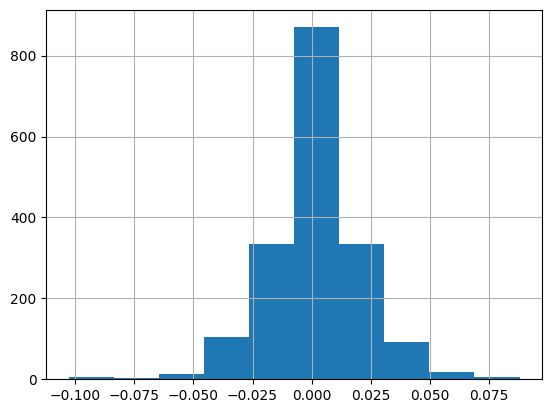

In [7]:
panel['y_excess_lead'].hist()



# Adding context variables

1. **Price-based / Technical features**

These come straight from the ETF’s own return history:

-   Lagged returns (1-week, 2-week, 4-week, etc.)
-   Momentum: rolling cumulative returns over 3m, 6m, 12m.
-   Volatility measures: rolling standard deviation (e.g. 4w, 12w).
-   Drawdown: max decline from recent peak.
-   Skew/kurtosis of rolling returns.
-   Moving averages (20-day, 50-day, 200-day) and crossovers.
-   RSI / stochastic oscillators (basic technicals).

2. **Cross-sectional / Fundamental ETF descriptors**

Even though ETFs don’t have classic accounting statements, they inherit factor exposures:

-   Asset class tags (equity, fixed income, REIT, emerging markets, etc.).
-   Region/country exposures (developed, EM, Asia, US).
-   Style (value vs growth, small vs large cap).
-   Duration / credit exposure for bond ETFs (BYLD, HYEM, VWOB).
-   Sector tilts (VNQ/VNQI = real estate). 

These can be encoded as categorical one-hot vectors or embeddings.

3. **Market-wide / Macro features**

All ETFs are affected by common risk factors:

-   Equity market index returns (S&P 500, MSCI World).
-   Bond yields: 2y, 10y Treasury yields, yield curve slope.
-   Credit spreads: investment grade vs HY spread.
-   FX indices (USD index).
-   Commodities: oil, gold.
-   Volatility index (VIX).
-   Inflation surprise indices, unemployment, PMI (if you want to bring in economic releases).

These are typically aligned to the same horizon as your ETF panel (weekly).


4. **Calendar / Regime features**

Markets behave differently under certain regimes:

-   Month of year / quarter of year (seasonality effects).

-   Week-of-month / day-of-week (if you go daily).

-   Recession vs expansion flags (NBER or proxy).

-   Fed meeting weeks, earnings season flags.

-   Volatility regime (low/high VIX).

# 1. Price based features

**Note**
All features are computed on resampled weekly closes to match your Friday→Friday target and avoid look-ahead.

-   Momentum features (e.g., mom_13w) are cumulative: 
(1 + 𝑟) ^ 13 −1

-   Volatility uses weekly returns’ std, not price std.

-   RSI uses Wilder smoothing on weekly price changes (rsi_14w).

-   Expect NaNs at the beginning for windows like 26 or 52 weeks—normal. Inner-joining with the target naturally trims the very early warm-up period.


### 📊 Price-Based Feature Definitions

| Feature       | Definition                                                                                   | Lookback Window            |
|---------------|-----------------------------------------------------------------------------------------------|----------------------------|
| **ret_1w**    | Simple return over the past 1 week.                                                           | 1 week                     |
| **ret_2w**    | Cumulative return over the past 2 weeks.                                                      | 2 weeks                    |
| **ret_4w**    | Cumulative return over the past 4 weeks (~1 month).                                           | 4 weeks                    |
| **mom_13w**   | Momentum: cumulative return over the past 13 weeks (~quarter).                                | 13 weeks (~3 months)       |
| **mom_26w**   | Momentum: cumulative return over the past 26 weeks (~half year).                              | 26 weeks (~6 months)       |
| **mom_52w**   | Momentum: cumulative return over the past 52 weeks (~1 year).                                 | 52 weeks (~12 months)      |
| **vol_4w**    | Rolling standard deviation of weekly returns.                                                 | 4 weeks                    |
| **vol_12w**   | Rolling standard deviation of weekly returns.                                                 | 12 weeks (~3 months)       |
| **vol_26w**   | Rolling standard deviation of weekly returns.                                                 | 26 weeks (~6 months)       |
| **dd_26w**    | Current drawdown relative to rolling maximum price (how far below recent peak).               | 26 weeks (~6 months)       |
| **ma_4w**     | 4-week simple moving average of price.                                                        | 4 weeks                    |
| **ma_12w**    | 12-week simple moving average of price.                                                       | 12 weeks (~3 months)       |
| **ma_26w**    | 26-week simple moving average of price.                                                       | 26 weeks (~6 months)       |
| **px_ma4_gap**  | % difference between price and its 4-week moving average.                                    | 4 weeks                    |
| **px_ma12_gap** | % difference between price and its 12-week moving average.                                   | 12 weeks (~3 months)       |
| **px_ma26_gap** | % difference between price and its 26-week moving average.                                   | 26 weeks (~6 months)       |
| **skew_12w**  | Skewness of weekly returns distribution (asymmetry).                                          | 12 weeks (~3 months)       |
| **kurt_12w**  | Excess kurtosis of weekly returns distribution (fat tails vs. normal).                        | 12 weeks (~3 months)       |
| **rsi_14w**   | Relative Strength Index (RSI) based on weekly closes. >70 = “overbought”, <30 = “oversold”.   | 14 weeks                   |

In [8]:
# ========================
# Price-based feature pack
# ========================

def _rolling_cumret(r: pd.Series, win: int) -> pd.Series:
    """(1+r).rolling(win).apply(prod)-1, stable for NaNs."""
    return (1.0 + r).rolling(window=win, min_periods=win).apply(np.prod, raw=True) - 1.0

def _rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    """Wilder-style RSI on the *resampled* price series (weekly here)."""
    delta = prices.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    # Wilder's smoothing
    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi

def _weekly_price_table(prices_wide: pd.DataFrame, freq: str = "W-FRI") -> pd.DataFrame:
    """Resample to weekly (Friday) closes, consistent with y_excess_lead."""
    px_w = prices_wide.resample(freq).last().dropna(how="all")
    return px_w

def _weekly_return_table(px_w: pd.DataFrame) -> pd.DataFrame:
    """Simple weekly returns from resampled prices."""
    return px_w.pct_change()

def compute_price_features_for_one(
    px_w: pd.Series,  # weekly price series for one ETF
) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by date with all price-based features for one asset.
    All features use ONLY data up to 'date' (no leakage).
    """
    s = px_w.dropna()
    ret = s.pct_change()

    # --- Last-week and multi-week momentum (simple cumulative returns) ---
    feat = pd.DataFrame(index=s.index)
    feat["ret_1w"]  = ret                                  # last week return
    feat["ret_2w"]  = _rolling_cumret(ret, 2)
    feat["ret_4w"]  = _rolling_cumret(ret, 4)
    feat["mom_13w"] = _rolling_cumret(ret, 13)             # ~3m
    feat["mom_26w"] = _rolling_cumret(ret, 26)             # ~6m
    feat["mom_52w"] = _rolling_cumret(ret, 52)             # ~12m

    # --- Volatility (std of weekly returns) ---
    feat["vol_4w"]  = ret.rolling(4,  min_periods=4).std()
    feat["vol_12w"] = ret.rolling(12, min_periods=12).std()
    feat["vol_26w"] = ret.rolling(26, min_periods=26).std()

    # --- Drawdown (relative to rolling max) ---
    rolling_max_26 = s.rolling(26, min_periods=26).max()
    feat["dd_26w"] = (s / rolling_max_26) - 1.0

    # --- Moving averages & price gaps ---
    ma4  = s.rolling(4,  min_periods=4).mean()
    ma12 = s.rolling(12, min_periods=12).mean()
    ma26 = s.rolling(26, min_periods=26).mean()
    feat["ma_4w"]   = ma4
    feat["ma_12w"]  = ma12
    feat["ma_26w"]  = ma26
    feat["px_ma4_gap"]  = (s / ma4)  - 1.0
    feat["px_ma12_gap"] = (s / ma12) - 1.0
    feat["px_ma26_gap"] = (s / ma26) - 1.0

    # --- Higher moments of returns ---
    feat["skew_12w"] = ret.rolling(12, min_periods=12).skew()
    # Fisher's definition (excess kurtosis): pandas' .kurt() already returns Fisher by default
    feat["kurt_12w"] = ret.rolling(12, min_periods=12).kurt()

    # --- RSI on weekly prices ---
    feat["rsi_14w"] = _rsi(s, period=14)

    return feat

def build_price_features_panel(
    tickers, start, end=None, horizon="weekly"
) -> pd.DataFrame:
    """
    Builds a LONG panel of price-based features aligned to your weekly calendar.
    Columns: date, asset_id, <features...>
    """
    # Use the same price fetcher you already have
    prices = fetch_prices(tickers, start, end)

    # Pick calendar matching your target
    if horizon.lower() == "weekly":
        freq = "W-FRI"
    elif horizon.lower() == "monthly":
        freq = "M"
    else:
        # If you use fixed daily horizons, you could compute daily features instead.
        # For now we match your weekly setup.
        freq = "W-FRI"

    px_w = _weekly_price_table(prices, freq=freq)

    # Compute features per asset and stack long
    long_rows = []
    for tk in px_w.columns:
        f = compute_price_features_for_one(px_w[tk])
        f = f.rename_axis("date").reset_index()
        f.insert(1, "asset_id", tk)
        long_rows.append(f)

    features_long = pd.concat(long_rows, axis=0).sort_values(["date", "asset_id"]).reset_index(drop=True)
    return features_long

def build_dataset_with_features(
    tickers, start, end=None, horizon="weekly", fixed_h_days=5
) -> pd.DataFrame:
    """
    Convenience wrapper: builds your target panel and merges price features.
    Returns a single LONG dataframe ready for modeling.
    """
    target_panel = build_long_panel(tickers, start, end, horizon=horizon, fixed_h_days=fixed_h_days)
    feat_panel   = build_price_features_panel(tickers, start, end, horizon=horizon)

    # Inner-join: keeps only dates/assets present in BOTH (prevents leakage/misalignment)
    df = pd.merge(target_panel, feat_panel, on=["date", "asset_id"], how="inner")
    # Optional: drop rows that still have too many NaNs (from warm-up windows)
    # df = df.dropna(subset=["ret_1w","vol_4w","mom_13w"])  # minimal viable set
    return df


2. **Cross-sectional / Fundamental ETF descriptors**

In [9]:
# get etf categories 
categories = {}

for asset in assets:
    ticker = yf.Ticker(asset)
    info = ticker.info
    category = info.get('category', 'Unknown')
    categories[asset] = category
categories

{'AVEM': 'Diversified Emerging Mkts',
 'AVES': 'Diversified Emerging Mkts',
 'BYLD': 'Multisector Bond',
 'ESGD': 'Foreign Large Blend',
 'HYEM': 'Emerging Markets Bond',
 'IEF': 'Long Government',
 'ISCF': 'Foreign Small/Mid Blend',
 'SNPE': 'Large Blend',
 'VBK': 'Small Growth',
 'VNQ': 'Real Estate',
 'VNQI': 'Global Real Estate',
 'VWOB': 'Emerging Markets Bond',
 'XMMO': 'Mid-Cap Blend'}

In [11]:
fundamentals = {}

asset_class = {'AVEM': 'Equity',
 'AVES': 'Equity',
 'BYLD': 'Fixed Income',
 'ESGD': 'Equity',
 'HYEM': 'Fixed Income',
 'IEF': 'Fixed Income',
 'ISCF': 'Equity',
 'SNPE': 'Equity',
 'VBK': 'Equity',
 'VNQ': 'Real Estate',
 'VNQI': 'Real Estate',
 'VWOB': 'Fixed Income',
 'XMMO': 'Equity'}

region = {'AVEM': 'International',
 'AVES': 'International',
 'BYLD': 'US',
 'ESGD': 'International',
 'HYEM': 'International',
 'IEF': 'US',
 'ISCF': 'International',
 'SNPE': 'US',
 'VBK': 'US',
 'VNQ': 'US',
 'VNQI': 'International',
 'VWOB': 'International',
 'XMMO': 'US'}

fundamentals['asset_class'] = asset_class
fundamentals['region'] = region



# etf = yf.Ticker('ESGD')

# fd = etf.funds_data              # or: etf.get_funds_data()
# fd.sector_weightings             # -> dict of sector -> weight (0–1)
# fd.top_holdings                  # -> DataFrame of top holdings (symbol, name, weight)
# fd.equity_holdings               # -> summary ratios (P/E, P/B, etc.)
# fd.asset_classes                 # -> {'stocks': ..., 'bonds': ...}
# fd.__dict__

3. **Market-wide / Macro features**


| **Feature** | **Definition** | **Lookback Window** |
|-------------|----------------|---------------------|
| `spy_ret_1w`, `acwi_ret_1w`, `veu_ret_1w`, `eem_ret_1w` | Weekly return of broad equity indices (US, Global, DM ex-US, EM) | 1 week |
| `*_mom_4w`, `*_mom_13w`, `*_mom_26w` | Cumulative momentum return over past 4, 13, or 26 weeks | 4w, 13w, 26w |
| `*_vol_12w` | Standard deviation of weekly returns | 12 weeks |
| `*_dd_52w` | Drawdown vs. rolling 52-week high | 52 weeks |
| `vix_level` | CBOE VIX index level (weekly last) | — |
| `vix_chg_1w` | Weekly % change in VIX | 1 week |
| `vix_z_52w` | Z-score of VIX relative to trailing mean/stdev | 52 weeks |
| `usd_ret_1w`, `oil_ret_1w`, `gold_ret_1w`, `copper_ret_1w` | Weekly return of dollar proxy (UUP) and commodities (WTI, Gold, Copper) | 1 week |
| `usd_mom_13w`, `oil_mom_13w`, `gold_mom_13w`, `copper_mom_13w` | 13-week cumulative return (momentum) | 13 weeks |
| `usd_mom_26w`, `oil_mom_26w`, `gold_mom_26w`, `copper_mom_26w` | 26-week cumulative return (momentum) | 26 weeks |
| `*_vol_12w` (for USD/commodities) | Standard deviation of weekly returns | 12 weeks |
| `hy_ig_rel_1w` | Weekly relative return: High Yield (HYG) vs IG Corp (LQD) | 1 week |
| `hy_ig_rel_13w`, `hy_ig_rel_26w` | Rolling relative performance HY vs IG | 13w, 26w |
| `emb_ief_rel_1w` | Weekly relative return: EM sovereign bonds (EMB) vs Treasuries (IEF) | 1 week |
| `emb_ief_rel_13w`, `emb_ief_rel_26w` | Rolling relative performance EM vs Treasuries | 13w, 26w |
| `t10y_level`, `t05y_level`, `t02y_level` | Yield level (decimal, not %) for 10y, 5y, 3m Treasuries | — |
| `t10y_chg_bp_1w`, `t05y_chg_bp_1w` | Weekly change in 10y / 5y yield (basis points) | 1 week |
| `slope_10y_3m`, `slope_10y_3m_bp` | 10y minus 3m term spread (decimal, bp) | — |
| `slope_chg_bp_4w` | 4-week change in 10y–3m slope (basis points) | 4 weeks |
| `slope_z_104w` | Z-score of 10y–3m slope vs trailing 2-year distribution | 104 weeks |
| `curve_proxy`, `curve_proxy_bp` | Proxy curvature = (10y – 2×5y + 3m), in decimal and bp | — |

In [12]:
"""
macro_features.py

Build market-wide macro features to merge into your ETF dataset.
- Uses daily market proxies via yfinance, resampled to a weekly (Friday) calendar.
- All features are computed with information available as of each week-end date (no look-ahead).
- Safe to inner-join on 'date' with your existing weekly dataset.

Dependencies:
    pip install yfinance pandas numpy

Example:
    from macro_features import build_macro_features, merge_macro_features

    macro = build_macro_features(start="2023-01-01", end=None, freq="W-FRI")
    df_final = merge_macro_features(df_base, macro)  # df_base must have a 'date' column
"""
from __future__ import annotations
import numpy as np
import pandas as pd
import yfinance as yf
from typing import Dict, List, Optional

# ---------------------------
# Utilities
# ---------------------------

def _ensure_datetime_index(df: pd.DataFrame | pd.Series) -> pd.DataFrame | pd.Series:
    out = df.copy()
    out.index = pd.to_datetime(out.index)
    return out

def _fetch_adj_close(tickers: List[str], start: str, end: Optional[str] = None) -> pd.DataFrame:
    """
    Robustly fetch Adjusted Close for multiple tickers using yfinance.
    Returns wide DataFrame with columns = tickers, index = trading days.
    """
    px = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        interval="1d",
        group_by="ticker",
        auto_adjust=False,
        progress=False,
        threads=True,
    )
    # Normalize shape across yfinance versions
    if isinstance(px.columns, pd.MultiIndex):
        cols = []
        for tk in tickers:
            if (tk, "Adj Close") in px.columns:
                cols.append(px[(tk, "Adj Close")].rename(tk))
            elif (tk, "Close") in px.columns:
                cols.append(px[(tk, "Close")].rename(tk))
        out = pd.concat(cols, axis=1)
    else:
        # Single ticker case
        base = "Adj Close" if "Adj Close" in px.columns else "Close"
        out = px[[base]]
        out.columns = [tickers[0]]
    out = _ensure_datetime_index(out).sort_index().dropna(how="all")
    return out

def _weekly_last(df: pd.DataFrame, freq: str = "W-FRI") -> pd.DataFrame:
    """Resample to weekly (Friday) closes to match your target calendar."""
    return df.resample(freq).last().dropna(how="all")

def _pct_change(s: pd.Series, periods: int = 1) -> pd.Series:
    return s.pct_change(periods=periods)

def _rolling_cumret(r: pd.Series, win: int) -> pd.Series:
    """(1+r).rolling(win).apply(prod)-1; robust to NaNs."""
    return (1.0 + r).rolling(window=win, min_periods=win).apply(np.prod, raw=True) - 1.0

def _zscore(s: pd.Series, win: int) -> pd.Series:
    m = s.rolling(win, min_periods=win).mean()
    v = s.rolling(win, min_periods=win).std()
    return (s - m) / v.replace(0, np.nan)

# ---------------------------
# Macro universe (proxies)
# ---------------------------
MACRO_TICKERS: Dict[str, str] = {
    # Equity market and volatility
    "spy": "SPY",        # US equity market proxy
    "acwi": "ACWI",      # Global equity
    "eem": "EEM",        # EM equity proxy
    "veu": "VEU",        # DM ex-US equity proxy
    "vix": "^VIX",       # Implied vol (level index)

    # US Rates (Yahoo yields are in percent; ^TNX is 10x yield)
    "t10y": "^TNX",      # 10Y UST yield (%*10)
    "t05y": "^FVX",      # 5Y UST yield (%*10)
    "t02y": "^IRX",      # 13W T-bill (%), proxy for short end

    # Dollar
    "usd": "UUP",        # DXY proxy (ETF)

    # Commodities
    "oil": "CL=F",       # WTI front month futures
    "gold": "GC=F",      # Gold futures
    "copper": "HG=F",    # Copper futures

    # Credit proxies (spreads via relative returns)
    "hyg": "HYG",        # US High Yield
    "lqd": "LQD",        # US IG Corp
    "emb": "EMB",        # EM Sovereign (USD)
    "ief": "IEF",        # 7-10Y Treasuries (duration-matched)
}

# ---------------------------
# Feature engineering
# ---------------------------

def _rate_from_yahoo_yield(y: pd.Series, code: str) -> pd.Series:
    """
    Convert Yahoo Finance Treasury yield tickers to DECIMAL yields.
    - ^TNX and ^FVX are quoted as percent * 10 (e.g., 45.6 => 4.56% => 0.0456).
    - ^IRX is a percent (e.g., 5.30 => 5.30% => 0.0530).
    Returns a decimal (e.g., 0.0456).
    """
    s = y.astype(float)
    if code in ("^TNX", "^FVX"):
        return (s / 10.0) / 100.0
    elif code in ("^IRX",):
        return s / 100.0
    else:
        return s / 100.0

def _build_levels_and_returns(px_w: pd.DataFrame) -> pd.DataFrame:
    """
    Compute core market levels and returns (weekly).
    """
    feat = pd.DataFrame(index=px_w.index)

    # Equity returns & momentum
    for label in ["spy", "acwi", "veu", "eem"]:
        if label in px_w:
            r = px_w[label].pct_change()
            feat[f"{label}_ret_1w"] = r
            feat[f"{label}_mom_4w"] = _rolling_cumret(r, 4)
            feat[f"{label}_mom_13w"] = _rolling_cumret(r, 13)
            feat[f"{label}_mom_26w"] = _rolling_cumret(r, 26)
            feat[f"{label}_vol_12w"] = r.rolling(12, min_periods=12).std()
            # drawdown vs 52w high
            rolling_max_52 = px_w[label].rolling(52, min_periods=52).max()
            feat[f"{label}_dd_52w"] = (px_w[label] / rolling_max_52) - 1.0

    # VIX level and changes
    if "vix" in px_w:
        vix = px_w["vix"]
        feat["vix_level"] = vix
        feat["vix_chg_1w"] = vix.pct_change()
        feat["vix_z_52w"] = _zscore(vix, 52)

    # Dollar & commodities: weekly returns and momentum
    for label in ["usd", "oil", "gold", "copper"]:
        if label in px_w:
            r = px_w[label].pct_change()
            feat[f"{label}_ret_1w"] = r
            feat[f"{label}_mom_13w"] = _rolling_cumret(r, 13)
            feat[f"{label}_mom_26w"] = _rolling_cumret(r, 26)
            feat[f"{label}_vol_12w"] = r.rolling(12, min_periods=12).std()

    # Credit spread proxies (relative performance)
    # HY spread proxy: HYG vs LQD (higher = tightening, lower = widening)
    if ("hyg" in px_w) and ("lqd" in px_w):
        r_hyg = px_w["hyg"].pct_change()
        r_lqd = px_w["lqd"].pct_change()
        rel = (1 + r_hyg) / (1 + r_lqd) - 1.0
        feat["hy_ig_rel_1w"] = rel
        feat["hy_ig_rel_13w"] = _rolling_cumret(rel, 13)
        feat["hy_ig_rel_26w"] = _rolling_cumret(rel, 26)

    # EM spread proxy: EMB vs IEF
    if ("emb" in px_w) and ("ief" in px_w):
        r_emb = px_w["emb"].pct_change()
        r_ief = px_w["ief"].pct_change()
        rel = (1 + r_emb) / (1 + r_ief) - 1.0
        feat["emb_ief_rel_1w"] = rel
        feat["emb_ief_rel_13w"] = _rolling_cumret(rel, 13)
        feat["emb_ief_rel_26w"] = _rolling_cumret(rel, 26)

    return feat

def _build_rates_features(yields_w: pd.DataFrame) -> pd.DataFrame:
    """
    Build rates & curve features from weekly yields (decimal).
    """
    feat = pd.DataFrame(index=yields_w.index)

    # Levels
    if "t10y" in yields_w:
        feat["t10y_level"] = yields_w["t10y"]
        feat["t10y_chg_bp_1w"] = yields_w["t10y"].diff() * 1e4  # change in basis points

    if "t05y" in yields_w:
        feat["t05y_level"] = yields_w["t05y"]
        feat["t05y_chg_bp_1w"] = yields_w["t05y"].diff() * 1e4

    if {"t10y", "t02y"}.issubset(yields_w.columns):
        slope = yields_w["t10y"] - yields_w["t02y"]
        feat["slope_10y_3m"] = slope
        feat["slope_10y_3m_bp"] = slope * 1e4
        feat["slope_chg_bp_4w"] = slope.diff(4) * 1e4
        feat["slope_z_104w"] = _zscore(slope, 104)

    # Term structure curvature proxy (10y - 2*(5y) + 3m)
    have = set(yields_w.columns)
    if {"t10y", "t05y", "t02y"}.issubset(have):
        curv = yields_w["t10y"] - 2.0 * yields_w["t05y"] + yields_w["t02y"]
        feat["curve_proxy"] = curv
        feat["curve_proxy_bp"] = curv * 1e4

    return feat

# ---------------------------
# Public API
# ---------------------------

def build_macro_features(start: str, end: Optional[str] = None, freq: str = "W-FRI") -> pd.DataFrame:
    """
    Build a weekly table of macro features.

    Returns:
        DataFrame with columns:
            ['date', <macro columns...>]
    """
    # 1) Fetch prices for proxies that are price-based (equities, ETFs, futures, VIX treated as level)
    price_like = ["spy", "acwi", "eem", "veu", "vix", "usd", "oil", "gold", "copper", "hyg", "lqd", "emb", "ief"]
    tickers_price = [MACRO_TICKERS[k] for k in price_like]
    px = _fetch_adj_close(tickers_price, start=start, end=end)
    # Map columns back to our keys
    colmap = {MACRO_TICKERS[k]: k for k in price_like if MACRO_TICKERS[k] in px.columns}
    px = px.rename(columns=colmap)
    px_w = _weekly_last(px, freq=freq)

    # 2) Fetch yields for rate features
    yield_keys = ["t10y", "t05y", "t02y"]
    tickers_y = [MACRO_TICKERS[k] for k in yield_keys]
    yld = _fetch_adj_close(tickers_y, start=start, end=end)
    # Convert Yahoo yield tickers to DECIMAL yields
    yld_conv = pd.DataFrame(index=yld.index)
    for key in yield_keys:
        tk = MACRO_TICKERS[key]
        if tk in yld.columns:
            yld_conv[key] = _rate_from_yahoo_yield(yld[tk], tk)
    yld_w = _weekly_last(yld_conv, freq=freq)

    # 3) Build feature blocks
    feat_levels = _build_levels_and_returns(px_w)
    feat_rates  = _build_rates_features(yld_w)

    # 4) Merge blocks and return
    macro = pd.concat([feat_levels, feat_rates], axis=1).sort_index()
    macro = macro.reset_index().rename(columns={"index": "date"})
    return macro

def merge_macro_features(df_base: pd.DataFrame, macro: pd.DataFrame, how: str = "inner") -> pd.DataFrame:
    """
    Merge macro feature table into your existing LONG dataset on 'date'.
    Assumes df_base has a 'date' column in datetime (or parseable) format.
    """
    out = df_base.copy()
    if not np.issubdtype(out["date"].dtype, np.datetime64):
        out["date"] = pd.to_datetime(out["date"])
    macro2 = macro.copy()
    if not np.issubdtype(macro2["date"].dtype, np.datetime64):
        macro2["date"] = pd.to_datetime(macro2["date"])
    merged = pd.merge(out, macro2, on="date", how=how)
    return merged

In [14]:
# Target only (what you already do)
panel_y = build_long_panel(TICKERS, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)

# Price-based features
panel_x_price = build_price_features_panel(TICKERS, START, END, horizon=HORIZON)

# Macro features
macro = build_macro_features(start=START, end=END, freq="W-FRI")
macro.rename(columns={"Date": "date"}, inplace=True)


# merged dataset (X + y)
dataset = build_dataset_with_features(TICKERS, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)
dataset = merge_macro_features(dataset, macro, how="inner")
dataset.head()

,date,asset_id,y_excess_lead,ret_1w,ret_2w,ret_4w,mom_13w,mom_26w,mom_52w,vol_4w,...,t10y_level,t10y_chg_bp_1w,t05y_level,t05y_chg_bp_1w,slope_10y_3m,slope_10y_3m_bp,slope_chg_bp_4w,slope_z_104w,curve_proxy,curve_proxy_bp
0,2023-01-06,AVEM,2.8878%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3569%,NaN,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%
1,2023-01-06,AVES,2.7187%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3569%,NaN,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%
2,2023-01-06,BYLD,0.5377%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3569%,NaN,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%
3,2023-01-06,ESGD,3.5247%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3569%,NaN,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%
4,2023-01-06,HYEM,0.4976%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3569%,NaN,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%


In [16]:
# adding in fundamentals


# Map the dictionaries to create new columns
dataset['asset_class'] = dataset['asset_id'].map(fundamentals['asset_class'])
dataset['region'] = dataset['asset_id'].map(fundamentals['region'])

dataset.head()

,date,asset_id,y_excess_lead,ret_1w,ret_2w,ret_4w,mom_13w,mom_26w,mom_52w,vol_4w,...,t05y_level,t05y_chg_bp_1w,slope_10y_3m,slope_10y_3m_bp,slope_chg_bp_4w,slope_z_104w,curve_proxy,curve_proxy_bp,asset_class,region
0,2023-01-06,AVEM,2.8878%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%,Equity,International
1,2023-01-06,AVES,2.7187%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%,Equity,International
2,2023-01-06,BYLD,0.5377%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%,Fixed Income,US
3,2023-01-06,ESGD,3.5247%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%,Equity,International
4,2023-01-06,HYEM,0.4976%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.3712%,NaN,-4.1361%,-41361.0003%,NaN,NaN,4.1075%,41075.0005%,Fixed Income,International


# 📅 Calendar & Regime Feature Engineering


| Feature                  | Definition                                                                                  |
|---------------------------|----------------------------------------------------------------------------------------------|
| **month**                | Month of year (1–12). Captures seasonal effects such as “January effect.”                   |
| **quarter**              | Quarter of year (1–4). Useful for fiscal and earnings cycles.                                |
| **week_of_month**        | Which week of the month the date falls into (1st, 2nd, 3rd, 4th, etc.).                      |
| **recession_flag**       | 1 if within known NBER recession periods (e.g., 2020 COVID recession), else 0.              |
| **recession_proxy**      | 1 if yield curve slope (10y – 3m) is negative (inversion proxy for recession), else 0.       |
| **fed_meeting_week**     | 1 if the week coincides with a scheduled FOMC meeting, else 0.                               |
| **earnings_season**      | 1 if within the first ~6 weeks of a quarter (bulk of corporate earnings releases).           |
| **earnings_season_quarters** | 1 if the month is Jan/Apr/Jul/Oct (quarters with heavy earnings concentration).           |
| **vix_high**             | 1 if VIX level is above its median (indicating high-volatility regime), else 0.              |
| **vix_regime**           | Categorization of VIX level into “low,” “medium,” or “high” based on quantile cutoffs.       |

In [17]:
def add_calendar_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add calendar and regime features to a long panel with 'date' column.
    Assumes 'date' is the prediction date (start of horizon, weekly).
    """

    df = df.copy()

    # --- Calendar features ---
    df["month"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter

    # Week-of-month: 1st, 2nd, 3rd, 4th week within the month
    df["week_of_month"] = df["date"].apply(lambda d: (d.day - 1) // 7 + 1)

    # --- Regime features ---

    # 1. Recession flag (proxy using NBER recession dates or fallback yield curve inversion)
    # NBER recession dates (US) - you can update with latest
    nber_recessions = [
        ("2020-02-01", "2020-04-30"),
        # Add historical or updated recessions if you want longer horizon
    ]
    df["recession_flag"] = 0
    for start, end in nber_recessions:
        df.loc[(df["date"] >= pd.to_datetime(start)) & (df["date"] <= pd.to_datetime(end)), "recession_flag"] = 1

    # If you want a proxy instead (yield curve inversion as recession indicator)
    if "slope_10y_3m" in df.columns:
        df["recession_proxy"] = (df["slope_10y_3m"] < 0).astype(int)

    # 2. Fed meeting weeks
    # Example: embed known 2023/24 FOMC meeting weeks; you can update annually
    fomc_meetings = [
        # 2023
        "2023-01-31", "2023-03-21", "2023-05-02", "2023-06-13", "2023-07-25",
        "2023-09-19", "2023-10-31", "2023-12-12",

        # 2024
        "2024-01-30", "2024-03-19", "2024-04-30", "2024-06-11", "2024-07-30",
        "2024-09-17", "2024-11-06", "2024-12-17",

        # 2025
        "2025-01-29", "2025-03-19", "2025-05-07", "2025-06-18", 
        "2025-07-30",# "2025-09-17", "2025-10-29", "2025-12-10"
    ]
    fomc_meetings = pd.to_datetime(fomc_meetings)
    df["fed_meeting_week"] = df["date"].isin(fomc_meetings).astype(int)

    # 3. Earnings season flag
    # Proxy: first 6 weeks of each quarter tend to be earnings-heavy
    df["earnings_season"] = df["date"].dt.day <= 42  # crude but effective for weekly freq
    # Or more precise: flag weeks in Jan/Apr/Jul/Oct (when >50% S&P reports)
    df["earnings_season_quarters"] = df["date"].dt.month.isin([1,4,7,10]).astype(int)

    # 4. Volatility regime (low/high VIX)
    if "vix_level" in df.columns:
        # Use rolling z-score or median split
        vix_median = df["vix_level"].median()
        df["vix_high"] = (df["vix_level"] > vix_median).astype(int)
        # Alternatively, use percentile thresholds
        df["vix_regime"] = pd.qcut(df["vix_level"], q=3, labels=["low","medium","high"])

    return df

In [18]:
data_set = add_calendar_regime_features(dataset)
data_set.head()

,date,asset_id,y_excess_lead,ret_1w,ret_2w,ret_4w,mom_13w,mom_26w,mom_52w,vol_4w,...,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season,earnings_season_quarters,vix_high,vix_regime
0,2023-01-06,AVEM,2.8878%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0,1,0,True,1,1,high
1,2023-01-06,AVES,2.7187%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0,1,0,True,1,1,high
2,2023-01-06,BYLD,0.5377%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0,1,0,True,1,1,high
3,2023-01-06,ESGD,3.5247%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0,1,0,True,1,1,high
4,2023-01-06,HYEM,0.4976%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0,1,0,True,1,1,high


array([[<Axes: title={'center': 'usd_mom_13w'}>,
        <Axes: title={'center': 'usd_mom_26w'}>,
        <Axes: title={'center': 'usd_vol_12w'}>],
       [<Axes: title={'center': 'oil_ret_1w'}>,
        <Axes: title={'center': 'oil_mom_13w'}>,
        <Axes: title={'center': 'oil_mom_26w'}>],
       [<Axes: title={'center': 'oil_vol_12w'}>,
        <Axes: title={'center': 'gold_ret_1w'}>,
        <Axes: title={'center': 'gold_mom_13w'}>],
       [<Axes: title={'center': 'gold_mom_26w'}>, <Axes: >, <Axes: >]],
      dtype=object)

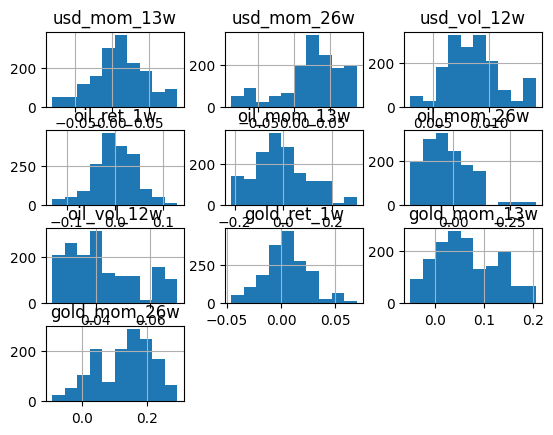

In [26]:
data_set.iloc[:, 50:60].hist()

In [29]:
import base64
import os

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def histogram_matrix(data: pd.DataFrame) -> go.Figure:
    """Plot the distribution of variables in dataset."""
    # Create subplots with up to 4 variables per row
    data = data.copy()
    max_vars_per_row = 4
    num_vars = len(data.columns)
    num_rows = (num_vars + max_vars_per_row - 1) // max_vars_per_row
    height = 300 if num_rows == 1 else 200 * num_rows
    fig = make_subplots(rows=num_rows, cols=max_vars_per_row, subplot_titles=data.columns)

    # Populate subplots with histograms
    for i, column in enumerate(data.columns, start=1):
        row = (i - 1) // max_vars_per_row + 1
        col = (i - 1) % max_vars_per_row + 1
        trace = go.Histogram(x=data[column], name=column, nbinsx=10, marker=dict(color="#33608D"))
        fig.add_trace(trace, row=row, col=col)

    # Update layout
    fig.update_layout(
        title="",
        title_x=0.5,
        height=height,
        width=200 * max_vars_per_row,
        showlegend=False,
        template="plotly_white",
        margin={"l": 25, "r": 25, "t": 25, "b": 25},
    )

    return fig

In [30]:
# Loop through the columns of the dataset in chunks of 10
for i in range(0, len(dataset.columns), 10):
    # Select a subset of 10 columns
    subset = dataset.iloc[:, i:i+10]
    
    # Render the histogram matrix for the subset
    fig = histogram_matrix(subset)
    fig.show()

In [35]:
# Step 1: Compute the correlation matrix
correlation_matrix = dataset.select_dtypes("number").corr()
correlation_matrix

,y_excess_lead,ret_1w,ret_2w,ret_4w,mom_13w,mom_26w,mom_52w,vol_4w,vol_12w,vol_26w,...,t10y_level,t10y_chg_bp_1w,t05y_level,t05y_chg_bp_1w,slope_10y_3m,slope_10y_3m_bp,slope_chg_bp_4w,slope_z_104w,curve_proxy,curve_proxy_bp
y_excess_lead,100.0000%,-8.3174%,-2.1555%,-6.0449%,-6.5662%,-8.3560%,-4.2135%,14.9831%,10.3595%,7.4406%,...,2.8354%,-4.8945%,-1.7253%,-3.1489%,1.2274%,1.2274%,5.9458%,-9.2921%,-0.5600%,-0.5600%
ret_1w,-8.3174%,100.0000%,67.0332%,47.4568%,24.4616%,16.2646%,15.8124%,11.8111%,10.2935%,7.0761%,...,-4.7382%,-19.0143%,-9.2914%,-16.9543%,-0.0985%,-0.0985%,1.7289%,-10.2574%,0.7598%,0.7598%
ret_2w,-2.1555%,67.0332%,100.0000%,69.3947%,35.9719%,22.8090%,22.2425%,11.4632%,13.3773%,9.2110%,...,-7.1919%,-17.0317%,-12.8445%,-12.2890%,-1.7457%,-1.7457%,-0.9966%,-20.5922%,2.6551%,2.6551%
ret_4w,-6.0449%,47.4568%,69.3947%,100.0000%,49.1840%,33.2308%,28.0434%,-1.6130%,15.7162%,11.7547%,...,-9.0599%,-8.8777%,-16.1766%,-5.7441%,-3.6291%,-3.6291%,-6.2648%,-34.4671%,4.8658%,4.8658%
mom_13w,-6.5662%,24.4616%,35.9719%,49.1840%,100.0000%,61.9435%,44.4185%,-4.2615%,3.5426%,15.1462%,...,-15.8112%,-0.6850%,-22.6010%,1.0564%,-3.6920%,-3.6920%,10.7381%,-52.0773%,4.9222%,4.9222%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
slope_10y_3m_bp,1.2274%,-0.0985%,-1.7457%,-3.6291%,-3.6920%,-13.5390%,-7.2529%,10.1669%,13.8209%,12.5872%,...,15.5678%,-0.4013%,-23.9776%,-1.8351%,100.0000%,100.0000%,24.0403%,48.3976%,-99.7883%,-99.7883%
slope_chg_bp_4w,5.9458%,1.7289%,-0.9966%,-6.2648%,10.7381%,8.8935%,27.3212%,11.4604%,-1.4984%,-4.6733%,...,15.2880%,-2.0801%,-2.7515%,-4.2027%,24.0403%,24.0403%,100.0000%,35.8093%,-22.6989%,-22.6989%
slope_z_104w,-9.2921%,-10.2574%,-20.5922%,-34.4671%,-52.0773%,-23.7885%,-4.5497%,0.9931%,-7.5428%,-12.4832%,...,50.6918%,0.1896%,82.7808%,-0.6733%,48.3976%,48.3976%,35.8093%,100.0000%,-84.3999%,-84.3999%
curve_proxy,-0.5600%,0.7598%,2.6551%,4.8658%,4.9222%,13.9241%,6.9404%,-10.3309%,-13.5985%,-12.3487%,...,-12.9289%,-0.1667%,24.0096%,0.9931%,-99.7883%,-99.7883%,-22.6989%,-84.3999%,100.0000%,100.0000%


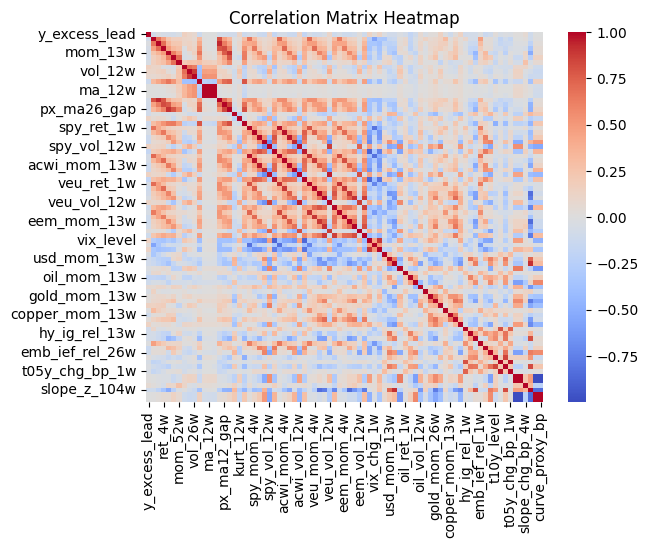

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
# Render the heatmap
plt.figure()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [47]:
correlation_matrix.iloc[60:, 60:]






,copper_mom_13w,copper_mom_26w,copper_vol_12w,hy_ig_rel_1w,hy_ig_rel_13w,hy_ig_rel_26w,emb_ief_rel_1w,emb_ief_rel_13w,emb_ief_rel_26w,t10y_level,t10y_chg_bp_1w,t05y_level,t05y_chg_bp_1w,slope_10y_3m,slope_10y_3m_bp,slope_chg_bp_4w,slope_z_104w,curve_proxy,curve_proxy_bp
copper_mom_13w,100.0000%,65.4652%,9.5768%,-6.0159%,-2.8593%,-12.2448%,-9.5347%,24.0792%,12.6683%,34.2497%,-3.0503%,24.8408%,-2.9869%,14.2766%,14.2766%,-8.2610%,-24.5207%,-13.8584%,-13.8584%
copper_mom_26w,65.4652%,100.0000%,32.1630%,-10.0561%,-20.9731%,-35.3006%,2.7422%,-10.0279%,1.9497%,7.9161%,-11.7112%,-12.4484%,-9.4261%,10.9451%,10.9451%,-15.3177%,-60.6515%,-9.1298%,-9.1298%
copper_vol_12w,9.5768%,32.1630%,100.0000%,-5.0229%,-32.7187%,-37.5285%,-3.2209%,-29.0196%,-55.0480%,8.5194%,-6.3034%,-30.5555%,-8.6037%,48.7140%,48.7140%,12.2798%,-70.0840%,-46.2282%,-46.2282%
hy_ig_rel_1w,-6.0159%,-10.0561%,-5.0229%,100.0000%,24.7360%,11.6746%,53.8435%,9.9782%,-1.1953%,15.6696%,80.2120%,17.3364%,73.5475%,-0.9083%,-0.9083%,-1.3766%,2.8881%,0.8746%,0.8746%
hy_ig_rel_13w,-2.8593%,-20.9731%,-32.7187%,24.7360%,100.0000%,46.5020%,17.1887%,52.5789%,39.4274%,53.7964%,25.3129%,66.5454%,23.8172%,2.9864%,2.9864%,3.8364%,34.3915%,-5.0215%,-5.0215%
hy_ig_rel_26w,-12.2448%,-35.3006%,-37.5285%,11.6746%,46.5020%,100.0000%,-4.0233%,-9.4711%,42.5121%,56.7359%,11.3839%,65.4963%,8.6083%,-7.7025%,-7.7025%,-20.9949%,80.4993%,5.9997%,5.9997%
emb_ief_rel_1w,-9.5347%,2.7422%,-3.2209%,53.8435%,17.1887%,-4.0233%,100.0000%,20.7054%,11.3930%,7.8123%,37.8674%,7.8433%,42.3649%,-3.9290%,-3.9290%,-0.5927%,-12.1576%,4.2514%,4.2514%
emb_ief_rel_13w,24.0792%,-10.0279%,-29.0196%,9.9782%,52.5789%,-9.4711%,20.7054%,100.0000%,38.8705%,24.4374%,14.4265%,40.9743%,15.6505%,-16.7456%,-16.7456%,16.0400%,-13.2383%,15.4790%,15.4790%
emb_ief_rel_26w,12.6683%,1.9497%,-55.0480%,-1.1953%,39.4274%,42.5121%,11.3930%,38.8705%,100.0000%,34.1721%,0.1776%,67.6175%,2.5504%,-57.9356%,-57.9356%,-19.9430%,63.2598%,56.6120%,56.6120%
t10y_level,34.2497%,7.9161%,8.5194%,15.6696%,53.7964%,56.7359%,7.8123%,24.4374%,34.1721%,100.0000%,17.0652%,84.4249%,15.5402%,15.5678%,15.5678%,15.2880%,50.6918%,-12.9289%,-12.9289%


In [48]:
dataset.columns

Index(['date', 'asset_id', 'y_excess_lead', 'ret_1w', 'ret_2w', 'ret_4w',
       'mom_13w', 'mom_26w', 'mom_52w', 'vol_4w', 'vol_12w', 'vol_26w',
       'dd_26w', 'ma_4w', 'ma_12w', 'ma_26w', 'px_ma4_gap', 'px_ma12_gap',
       'px_ma26_gap', 'skew_12w', 'kurt_12w', 'rsi_14w', 'spy_ret_1w',
       'spy_mom_4w', 'spy_mom_13w', 'spy_mom_26w', 'spy_vol_12w', 'spy_dd_52w',
       'acwi_ret_1w', 'acwi_mom_4w', 'acwi_mom_13w', 'acwi_mom_26w',
       'acwi_vol_12w', 'acwi_dd_52w', 'veu_ret_1w', 'veu_mom_4w',
       'veu_mom_13w', 'veu_mom_26w', 'veu_vol_12w', 'veu_dd_52w', 'eem_ret_1w',
       'eem_mom_4w', 'eem_mom_13w', 'eem_mom_26w', 'eem_vol_12w', 'eem_dd_52w',
       'vix_level', 'vix_chg_1w', 'vix_z_52w', 'usd_ret_1w', 'usd_mom_13w',
       'usd_mom_26w', 'usd_vol_12w', 'oil_ret_1w', 'oil_mom_13w',
       'oil_mom_26w', 'oil_vol_12w', 'gold_ret_1w', 'gold_mom_13w',
       'gold_mom_26w', 'gold_vol_12w', 'copper_ret_1w', 'copper_mom_13w',
       'copper_mom_26w', 'copper_vol_12w', 'hy_ig

In [49]:
# Need to drop redundant columns, like all that have basis points instead of decimals. 


# Assuming `df` is your dataset
columns_to_drop = [
    't10y_chg_bp_1w', 't05y_chg_bp_1w', 'slope_10y_3m_bp', 
    'curve_proxy_bp'  # Add any other basis points columns here
]

data_set = dataset.drop(columns=columns_to_drop, errors='ignore')



In [50]:
data_set.to_csv("initial_market_data.csv")

In [51]:
data_set.columns

Index(['date', 'asset_id', 'y_excess_lead', 'ret_1w', 'ret_2w', 'ret_4w',
       'mom_13w', 'mom_26w', 'mom_52w', 'vol_4w', 'vol_12w', 'vol_26w',
       'dd_26w', 'ma_4w', 'ma_12w', 'ma_26w', 'px_ma4_gap', 'px_ma12_gap',
       'px_ma26_gap', 'skew_12w', 'kurt_12w', 'rsi_14w', 'spy_ret_1w',
       'spy_mom_4w', 'spy_mom_13w', 'spy_mom_26w', 'spy_vol_12w', 'spy_dd_52w',
       'acwi_ret_1w', 'acwi_mom_4w', 'acwi_mom_13w', 'acwi_mom_26w',
       'acwi_vol_12w', 'acwi_dd_52w', 'veu_ret_1w', 'veu_mom_4w',
       'veu_mom_13w', 'veu_mom_26w', 'veu_vol_12w', 'veu_dd_52w', 'eem_ret_1w',
       'eem_mom_4w', 'eem_mom_13w', 'eem_mom_26w', 'eem_vol_12w', 'eem_dd_52w',
       'vix_level', 'vix_chg_1w', 'vix_z_52w', 'usd_ret_1w', 'usd_mom_13w',
       'usd_mom_26w', 'usd_vol_12w', 'oil_ret_1w', 'oil_mom_13w',
       'oil_mom_26w', 'oil_vol_12w', 'gold_ret_1w', 'gold_mom_13w',
       'gold_mom_26w', 'gold_vol_12w', 'copper_ret_1w', 'copper_mom_13w',
       'copper_mom_26w', 'copper_vol_12w', 'hy_ig

Next steps:
- start building an xgboost and do a time aware train/test split
- evaluate performance on the test set
- tune hyperparameters

In [ ]:
data